In [2]:
!pip install torchsummary
!pip install torchinfo albumentations
!pip install torchinfo

In [3]:
import torchinfo
import os
import torch
from torchsummary import summary
import pdb   # to debug


In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [6]:
from src.data_preprocessing_albumentation import cifar10Set
from src.model_architecture import *
from src.model_logs_metrics import *
from src.train_test import *
from src.scheduler import *
from src.utils import *

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.23 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [7]:
SEED = 11

# Set seed for reproducibility
torch.manual_seed(SEED)

# device:


In [8]:

# Check if GPU/CUDA is available
use_cuda, device = get_device()

if use_cuda:
    torch.cuda.manual_seed(SEED)

print(device)

cuda


# batch size

In [9]:
if use_cuda:
  batch_size = 512
else:
  batch_size = 64

In [10]:

# used for debugging purposes
%xmode Verbose

Exception reporting mode: Verbose


In [11]:

cifar10_data = cifar10Set(batch_size, shuffle=True)


100%|██████████| 170M/170M [00:03<00:00, 42.9MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


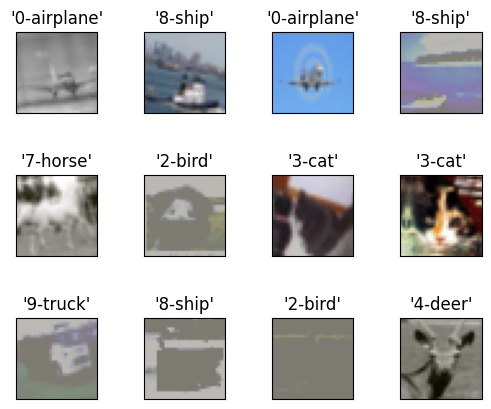

In [12]:
cifar10_data.show_dataset_images(figsize=(5, 5))

## call model architecture from class NEt in model_architecture.py
"""
- 0.05 is the dropout rate, meaning that during training, 5% of the neurons will be randomly "dropped out" or ignored.
- skip refers to the use of skip connections (also known as residual connections) in the model's architecture.
Skip connections allow data to flow through alternative paths in the network, which can help with training deeper networks and improving performance.
"""

In [13]:
model_less_than_200k_params = Net(dropout=0.05, skip=True)


In [14]:
model_less_than_200k_params.summary(input_size=(batch_size, 3, 32, 32))

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape              Param %
Net                                      [512, 3, 32, 32]          [512, 10]                 --                        --                             --
├─Sequential: 1-1                        [512, 3, 32, 32]          [512, 23, 32, 32]         --                        --                             --
│    └─convLayer: 2-1                    [512, 3, 32, 32]          [512, 23, 32, 32]         --                        --                             --
│    │    └─Sequential: 3-1              [512, 3, 32, 32]          [512, 23, 32, 32]         621                       --                          0.33%
│    │    └─BatchNorm2d: 3-2             [512, 23, 32, 32]         [512, 23, 32, 32]         46                        --                          0.02%
│    │    └─ReLU: 3-3                    [512, 23, 32, 32]         [512, 23, 32, 3

## Train
- epochs =100

In [15]:
EPOCHS = 100

optimizer = get_sgd_optimizer(model_less_than_200k_params)
scheduler = get_one_cycle_LR_scheduler(optimizer,
                                       cifar10_data.train_loader,
                                       EPOCHS)

/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [16]:
train_model = trainModel(model_less_than_200k_params, optimizer, scheduler,
                          train, test, cifar10_data.train_loader,
                          cifar10_data.test_loader, lr=0.05, epochs=EPOCHS,
                          device=device)

train_model.run_training_model()

| Epoch | LR       | Time    | TrainLoss | TrainAcc | TestLoss | TestAcc |
|     1 | 0.005000 | 00m 34s | 1.786113  |  23.19%  | 1.752152 |  34.89% |
|     2 | 0.005147 | 00m 36s | 1.592610  |   38.9%  | 1.442221 |  47.17% |
|     3 | 0.005585 | 00m 35s | 1.430722  |  45.01%  | 1.292742 |  53.26% |
|     4 | 0.006313 | 00m 35s | 1.342279  |  49.52%  | 1.211719 |  56.29% |
|     5 | 0.007326 | 00m 34s | 1.219370  |  52.83%  | 1.092536 |  60.78% |
|     6 | 0.008618 | 00m 34s | 1.053592  |  56.19%  | 1.025093 |  63.65% |
|     7 | 0.010180 | 00m 37s | 1.068770  |  58.35%  | 0.948241 |  66.45% |
|     8 | 0.012003 | 00m 35s | 1.124373  |  60.91%  | 0.889069 |  68.49% |
|     9 | 0.014076 | 00m 34s | 0.985389  |  62.84%  | 0.910533 |  67.82% |
|    10 | 0.016386 | 00m 34s | 0.960558  |  64.01%  | 0.821151 |  71.14% |
|    11 | 0.018919 | 00m 34s | 0.874718  |  65.77%  | 0.816984 |  71.37% |
|    12 | 0.021659 | 00m 36s | 0.871489  |  66.72%  | 0.789975 |  72.26% |
|    13 | 0.024589 | 00m 

## Plots

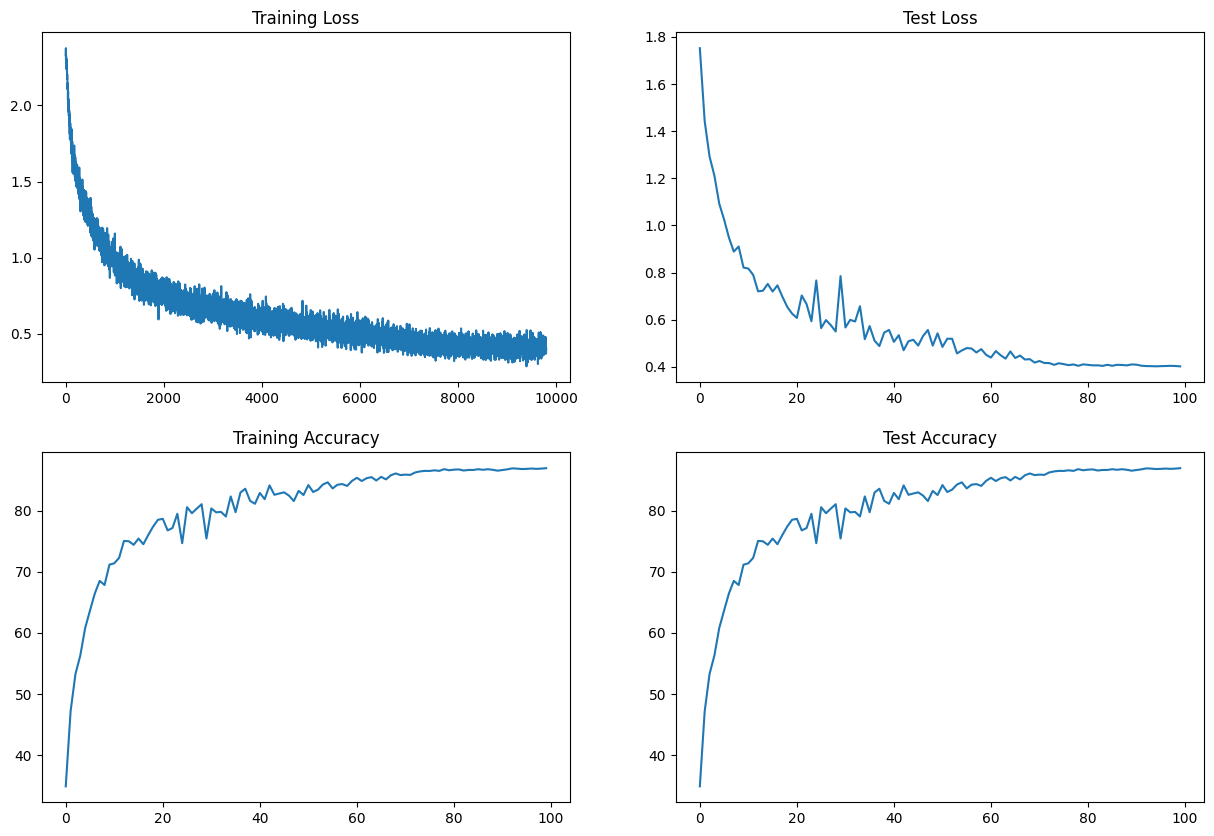

In [17]:
train_model.display_model_stats()

## Display incorrect predictions

In [18]:
model_incorrect_pred = get_incorrect_test_predictions(model_less_than_200k_params,
                                                    device,
                                                    cifar10_data.test_loader)

0 - 'airplane' 1 - 'automobile' 2 - 'bird' 3 - 'cat' 4 - 'deer' 5 - 'dog' 6 - 'frog' 7 - 'horse' 8 - 'ship' 9 - 'truck' 

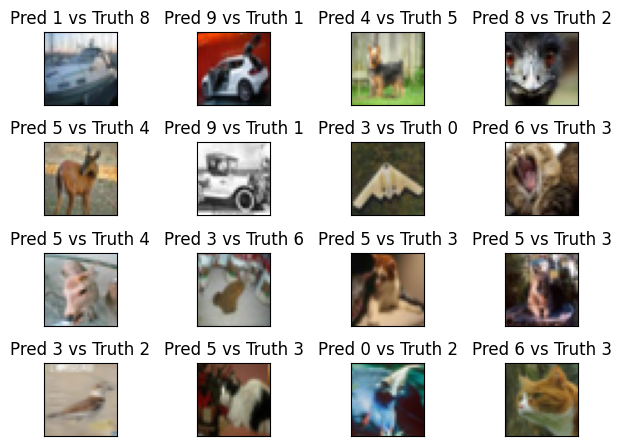

In [19]:

cifar10_data.show_cifar10_incorrect_predictions(denormalize=True,
                                                incorrect_prediction=model_incorrect_pred)

## Observations & Insights

## Code Block - Final Optimal Model
"""
**Target:**

* Network Architecture - Dilated Convolution + Depthwise Separable Convolution
* Layer Structure - C1 C2 C3 C4 Output + No MaxPooling, all convolution blocks have 3 layers and use 3x3 convolutions, GAP + FC + 1x1 convolutions
* Image Augmentation using Albumentation Transforms - Color Jitter + To Gray + Horizontal flip + Shift Scale Rotate + Coarse Dropout
* Skip connections used
* Batch Normalization used
* Dropout of 0.05 and one cycle learning rate with max LR as 0.1 used (class Net from model_architecture)
* L1 regularization degraded the performance and led the model to over-fitting, hence it is not used
* The receptive field we got with this network architecture is 48


**Results:**

* Parameters: 190,509
* Run 100 epochs
* Best Epoch 96
* Train accuracy:86.06%  Test Accuracy:86.81%
* Epoch 96 is best in terms of overfitting.

**Analysis**: trend in the first 100 epochs

* Model is slightly over fitted through out the training
* Scheduling OneCycle LR with pct_start = 0.4 gave better train/test accuracies
* Keeping the LR fixed at 0.05 and momentum at 0.9 did not show this kind of performance.
* The best test accuracy achieved with in first 100 epochs is 86.92% at 100th epoch.